<a href="https://colab.research.google.com/github/yarynauh/SQL_queries_example/blob/main/Global_Sales_EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
plt.style.use('fivethirtyeight')

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data overview

In [ ]:
%cd /content/drive/MyDrive/Module_task
countries = pd.read_csv("countries.csv", sep=',')
countries.head()

/content/drive/MyDrive/Module_task


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
%cd /content/drive/MyDrive/Module_task
event = pd.read_csv("events.csv", sep=',')
events.head()

/content/drive/MyDrive/Module_task


,order_id,order_date,ship_date,order_priority,sales_channel,units_sold,unit_price,unit_cost,product_category,country,country_code,region,sub_region,revenue,cost,profit,delivery_time_days,order_year,order_quarter,order_day_name
0,100640618,2014-10-08,2014-10-18,M,Online,650.0,205.70,117.11,Cereal,Norway,NOR,Europe,Northern Europe,133705.00,76121.50,57583.50,10,2014,2014Q4,Wednesday
1,100983083,2016-08-11,2016-08-11,C,Offline,1993.0,205.70,117.11,Cereal,Serbia,SRB,Europe,Southern Europe,409960.10,233400.23,176559.87,0,2016,2016Q3,Thursday
2,101025998,2014-07-18,2014-08-11,M,Online,4693.0,668.27,502.54,Household,Unknown,Unknown,Unknown,Unknown,3136191.11,2358420.22,777770.89,24,2014,2014Q3,Friday
3,102230632,2017-05-13,2017-06-13,L,Online,1171.0,109.28,35.84,Clothes,Montenegro,MNE,Europe,Southern Europe,127966.88,41968.64,85998.24,31,2017,2017Q2,Saturday
4,103435266,2012-08-11,2012-09-18,H,Offline,7648.0,47.45,31.79,Beverages,Serbia,SRB,Europe,Southern Europe,362897.60,243129.92,119767.68,38,2012,2012Q3,Saturday


In [ ]:
event.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
event.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


In [ ]:
%cd /content/drive/MyDrive/Module_task
products = pd.read_csv("products.csv", sep=',')
products.head()

/content/drive/MyDrive/Module_task


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


## Data cleaning

In [ ]:
# missing values by country in events

missing_country = event["Country Code"].isnull().sum()
pct_missing_country = (missing_country / len(event)) * 100
print(missing_country)
print(pct_missing_country)

82
6.165413533834586


In [ ]:
event["Country Code"] = event["Country Code"].fillna("Unknown")

#### Country Code had 82 missing values (6.17% of all rows), which exceeds the 5% threshold. Since these rows still contain valid order, sales, and revenue data, deleting them would meaningfully affect overall business metrics. Therefore, missing values were replaced with "Unknown" so these orders remain in the analysis but are clearly separated from orders with known countries.

In [ ]:
# missing values by Units Sold in events

missing_units = event["Units Sold"].isnull().sum()
pct_missing_units = (missing_units / len(event)) * 100
print(missing_units)
print(pct_missing_units)

2
0.15037593984962408


In [ ]:
event = event.dropna(subset=['Units Sold'])

#### Units Sold had only 2 missing values (0.15%). Since this is a key numeric metric directly tied to specific orders, imputing it could distort the analysis for those exact rows. Therefore, these 2 rows were removed.

In [ ]:
event.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1328 non-null   int64  
 1   Order Date      1328 non-null   object 
 2   Ship Date       1328 non-null   object 
 3   Order Priority  1328 non-null   object 
 4   Country Code    1328 non-null   object 
 5   Product ID      1328 non-null   int64  
 6   Sales Channel   1328 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1328 non-null   float64
 9   Unit Cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 114.1+ KB


In [ ]:
# Replacing missing entries in “countries” with “Unknown”

countries["alpha-2"] = countries["alpha-2"].fillna("Unknown")
countries["region"] = countries["region"].fillna("Unknown")
countries["sub-region"] = countries["sub-region"].fillna("Unknown")
print(countries.isnull().sum())

name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64


#### Missing values were found in the alpha-2, region, and sub-region columns of the “countries” table. All missing values were replaced with “Unknown” to ensure the dataset was clean.

In [ ]:
event["Order Priority"] = event["Order Priority"].astype("string")
event["Country Code"] = event["Country Code"].astype("string")
event["Sales Channel"] = event["Sales Channel"].astype("string")
event["Product ID"] = event["Product ID"].astype("string")
products["item_type"] = products["item_type"].astype("string")
products["id"] = products["id"].astype("string")
countries["alpha-3"] = countries["alpha-3"].astype("string")

#### Columns "Order Priority", "Country Code", "Sales Channel", and "Product ID" in event, as well as "item_type" and "id" in products and "alpha-3" in countries, were converted to the string dtype to ensure consistent text handling.

In [ ]:
event["Country Code"] = event["Country Code"].str.strip()
event["Product ID"] = event["Product ID"].str.strip()
event["Order Priority"] = event["Order Priority"].str.strip()
products["item_type"] = products["item_type"].str.strip()

#### Whitespace was stripped from Country Code, Product ID, Order Priority, and item_type to prevent duplicate categories caused by hidden leading/trailing spaces.

In [ ]:
event["Order Priority"] = event["Order Priority"].str.upper()
event["Country Code"] = event["Country Code"].str.upper()
event["Sales Channel"] = event["Sales Channel"].str.capitalize()

Converted to a single case: Order Priority and Country Code to uppercase, and Sales Channel to capitalized form, since these are categorical fields that should have a single consistent format for accurate grouping and analysis.

In [ ]:
event["Order Date"] = pd.to_datetime(event["Order Date"], format="%m/%d/%Y")
event["Ship Date"] = pd.to_datetime(event["Ship Date"], format="%m/%d/%Y")

#### Order Date and Ship Date were stored as object instead of proper date values. Both columns were converted to datetime using the explicit format %m/%d/%Y, matching the source format.

In [ ]:
print(event.dtypes)

Order ID                   int64
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Order Priority    string[python]
Country Code      string[python]
Product ID        string[python]
Sales Channel     string[python]
Units Sold               float64
Unit Price               float64
Unit Cost                float64
dtype: object


In [ ]:
# Checking for duplicates in event

print("Duplicates in event (by Order ID):", event["Order ID"].duplicated().sum())
print("Exact duplicate rows in event:", event.duplicated().sum())

Duplicates in event (by Order ID): 0
Exact duplicate rows in event: 0


In [ ]:
# Checking for duplicates in countries

print("Duplicates in countries (by alpha-3):", countries["alpha-3"].duplicated().sum())
print("Exact duplicate rows in countries:", countries.duplicated().sum())

Duplicates in countries (by alpha-3): 0
Exact duplicate rows in countries: 0


In [ ]:
# Checking for duplicates in products

print("Duplicates in products (by id):", products["id"].duplicated().sum())
print("Exact duplicate rows in products:", products.duplicated().sum())

Duplicates in products (by id): 0
Exact duplicate rows in products: 0


In [ ]:
# Checking for unique "Country Code" values

print(sorted(event["Country Code"].unique()))

['ALB', 'AND', 'ARM', 'AUT', 'BEL', 'BGR', 'BIH', 'BLR', 'CHE', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GEO', 'GRC', 'HRV', 'HUN', 'IRL', 'ISL', 'ITA', 'LIE', 'LTU', 'LUX', 'LVA', 'MCO', 'MKD', 'MLT', 'MNE', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'RUS', 'SMR', 'SRB', 'SVK', 'SVN', 'SWE', 'UKR', 'UNKNOWN']


In [ ]:
# Checking for unique "item_type" values

print(sorted(products["item_type"].unique()))

['Baby Food', 'Beverages', 'Cereal', 'Clothes', 'Cosmetics', 'Fruits', 'Household', 'Meat', 'Office Supplies', 'Personal Care', 'Snacks', 'Vegetables']


#### No duplicate rows were found in events (by Order ID), products (by id), or countries (by alpha-3), and no full-row duplicates were detected either. Additionally, checking the sorted unique values of Country Code and item_type confirmed there are no hidden duplicate categories caused by inconsistent casing or spacing.

In [ ]:
# Searching for anomalies

event[["Units Sold", "Unit Price", "Unit Cost"]].describe()

,Units Sold,Unit Price,Unit Cost
count,1328.000000,1328.000000,1328.000000
mean,4952.201807,264.913245,187.211521
std,2905.198996,217.386320,176.187801
min,2.000000,9.330000,6.920000
25%,2356.750000,81.730000,35.840000
50%,4962.000000,154.060000,97.440000
75%,7459.500000,437.200000,263.330000
max,9999.000000,668.270000,524.960000


In [ ]:
# Date logic check: The Ship Date cannot be earlier than the Order Date

invalid_dates = event[event["Ship Date"] < event["Order Date"]]
print(f"Number of rows where the delivery date is earlier than the order date: {len(invalid_dates)}")

Number of rows where the delivery date is earlier than the order date: 0


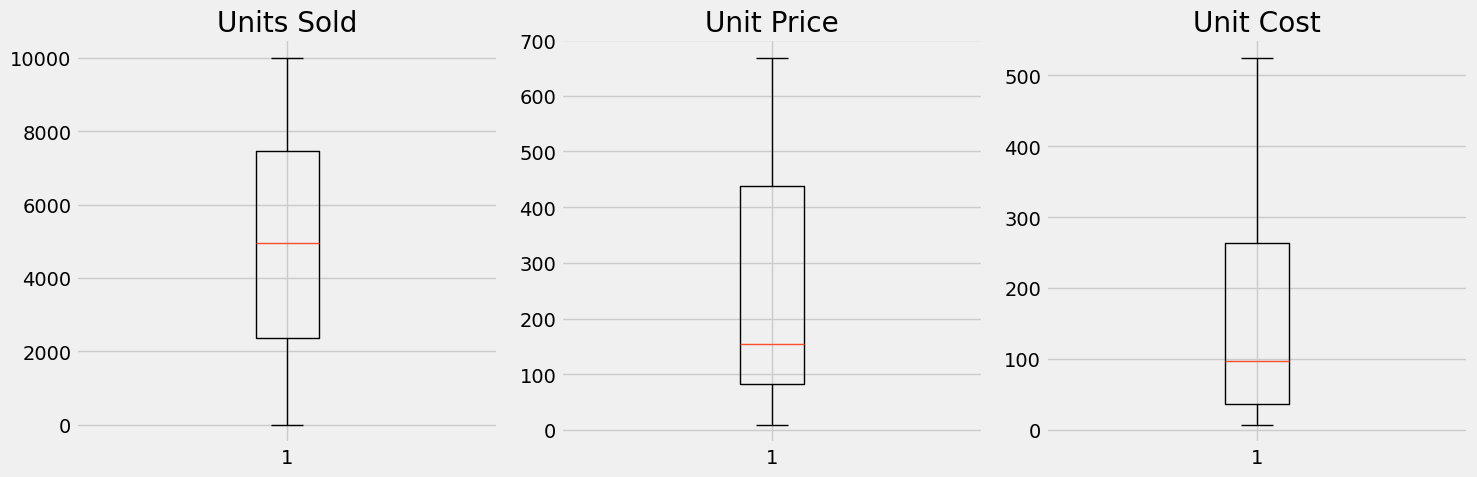

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(event["Units Sold"])
axes[0].set_title("Units Sold")

axes[1].boxplot(event["Unit Price"])
axes[1].set_title("Unit Price")

axes[2].boxplot(event["Unit Cost"])
axes[2].set_title("Unit Cost")

plt.tight_layout()
plt.show()

#### Boxplot analysis of Units Sold, Unit Price, and Unit Cost showed no points beyond the whiskers, meaning there are no outliers — all values fall within the expected natural range. Combined with the earlier checks (no missing values, no duplicates, no negative/zero values, no invalid dates), this confirms the dataset is fully cleaned and ready for merging and analysis.

## Data Merging

In [ ]:
# Combining event with products

events = event.merge(products, left_on="Product ID", right_on="id", how="left")
print(merged.shape)

(1328, 22)


In [ ]:
# Combining the result with “countries”

events = events.merge(countries, left_on="Country Code", right_on="alpha-3", how="left")
print(events.shape)

(1328, 17)


In [ ]:
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,Online,4693.0,668.27,502.54,7940,Household,NaN,NaN,<NA>,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


In [ ]:
# Checking unknown values after merge

print(events.isnull().sum())

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code       0
Product ID         0
Sales Channel      0
Units Sold         0
Unit Price         0
Unit Cost          0
id                 0
item_type          0
name              82
alpha-2           82
alpha-3           82
region            82
sub-region        82
dtype: int64


In [ ]:
# Filling in unknown values with “Unknown”

events["name"] = events["name"].fillna("Unknown")
events["alpha-2"] = events["alpha-2"].fillna("Unknown")
events["alpha-3"] = events["alpha-3"].fillna("Unknown")
events["region"] = events["region"].fillna("Unknown")
events["sub-region"] = events["sub-region"].fillna("Unknown")
print(events.isnull().sum())

Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
id                0
item_type         0
name              0
alpha-2           0
alpha-3           0
region            0
sub-region        0
dtype: int64


#### After merging events with products and countries, 82 new missing values appeared in the columns originating from countries. This matches exactly the 82 rows where Country Code was "Unknown", since these rows had no matching country in the countries table. These missing values were filled with "Unknown".

In [ ]:
# Renaming columns

events = events.rename(columns={
    "Order ID": "order_id",
    "Order Date": "order_date",
    "Ship Date": "ship_date",
    "Order Priority": "order_priority",
    "Sales Channel": "sales_channel",
    "Units Sold": "units_sold",
    "Unit Price": "unit_price",
    "Unit Cost": "unit_cost",
    "item_type": "product_category",
    "name": "country",
    "alpha-3": "country_code",
    "sub-region": "sub_region"})

In [ ]:
# Removing unnecessary columns

events = events.drop(columns=["Country Code", "Product ID", "id", "alpha-2"])

In [ ]:
events.head()

,order_id,order_date,ship_date,order_priority,sales_channel,units_sold,unit_price,unit_cost,product_category,country,country_code,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,Online,650.0,205.70,117.11,Cereal,Norway,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,Offline,1993.0,205.70,117.11,Cereal,Serbia,SRB,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Online,4693.0,668.27,502.54,Household,Unknown,Unknown,Unknown,Unknown
3,102230632,2017-05-13,2017-06-13,L,Online,1171.0,109.28,35.84,Clothes,Montenegro,MNE,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,Offline,7648.0,47.45,31.79,Beverages,Serbia,SRB,Europe,Southern Europe


#### Columns were renamed for clarity: name → country, item_type → product_category, and alpha-3 → country_code. Redundant columns were removed: Country Code (duplicate of country_code), Product ID and id (duplicates of each other, both representing the product identifier), and alpha-2 (not used anywhere in the analysis). All column names were standardized to snake_case format (lowercase, words separated by underscores) for consistency and easier access in code.

##  Data analysis and visualization

In [ ]:
# Creating calculation columns

events["revenue"] = events["units_sold"] * events["unit_price"]
events["cost"] = events["units_sold"] * events["unit_cost"]
events["profit"] = events["revenue"] - events["cost"]
events[["units_sold", "unit_price", "unit_cost", "revenue", "cost", "profit"]].head()

,units_sold,unit_price,unit_cost,revenue,cost,profit
0,650.0,205.70,117.11,133705.00,76121.50,57583.50
1,1993.0,205.70,117.11,409960.10,233400.23,176559.87
2,4693.0,668.27,502.54,3136191.11,2358420.22,777770.89
3,1171.0,109.28,35.84,127966.88,41968.64,85998.24
4,7648.0,47.45,31.79,362897.60,243129.92,119767.68


In [ ]:
# General business metrics

total_orders = events["order_id"].nunique()
total_revenue = events["revenue"].sum()
total_cost = events["cost"].sum()
total_profit = events["profit"].sum()
print(f"Total orders: {total_orders}")
print(f"Total revenue: {total_revenue}")
print(f"Total costs: {total_cost}")
print(f"Total profit: {total_profit}")

Total orders: 1328
Total revenue: 1702129408.21
Total costs: 1200694949.21
Total profit: 501434459.0


In [ ]:
profit_margin = (total_profit / total_revenue) * 100
print(f"Marginality (profit margin): {profit_margin}%")

Marginality (profit margin): 29.45924420207982%


#### Three new columns were calculated: revenue, cost, and profit. Based on these, the overall business metrics were computed: the dataset contains 1,328 unique orders, generating a total revenue of approximately \$1.70 billion, total costs of approximately \$1.20 billion, and a total profit of approximately \$501.4 million, resulting in a profit margin of roughly 29.5%.

In [ ]:
# grouping by each metric (product_category)

# Revenue by category
revenue_by_category = events.groupby("product_category")["revenue"].sum().reset_index()
revenue_by_category = revenue_by_category.sort_values("revenue", ascending=False)

# Costs by category
cost_by_category = events.groupby("product_category")["cost"].sum().reset_index()
cost_by_category = cost_by_category.sort_values("cost", ascending=False)

# Profit by category
profit_by_category = events.groupby("product_category")["profit"].sum().reset_index()
profit_by_category = profit_by_category.sort_values("profit", ascending=False)

# Popularity by category
popularity_by_category = events.groupby("product_category")["units_sold"].sum().reset_index()
popularity_by_category = popularity_by_category.sort_values("units_sold", ascending=False)

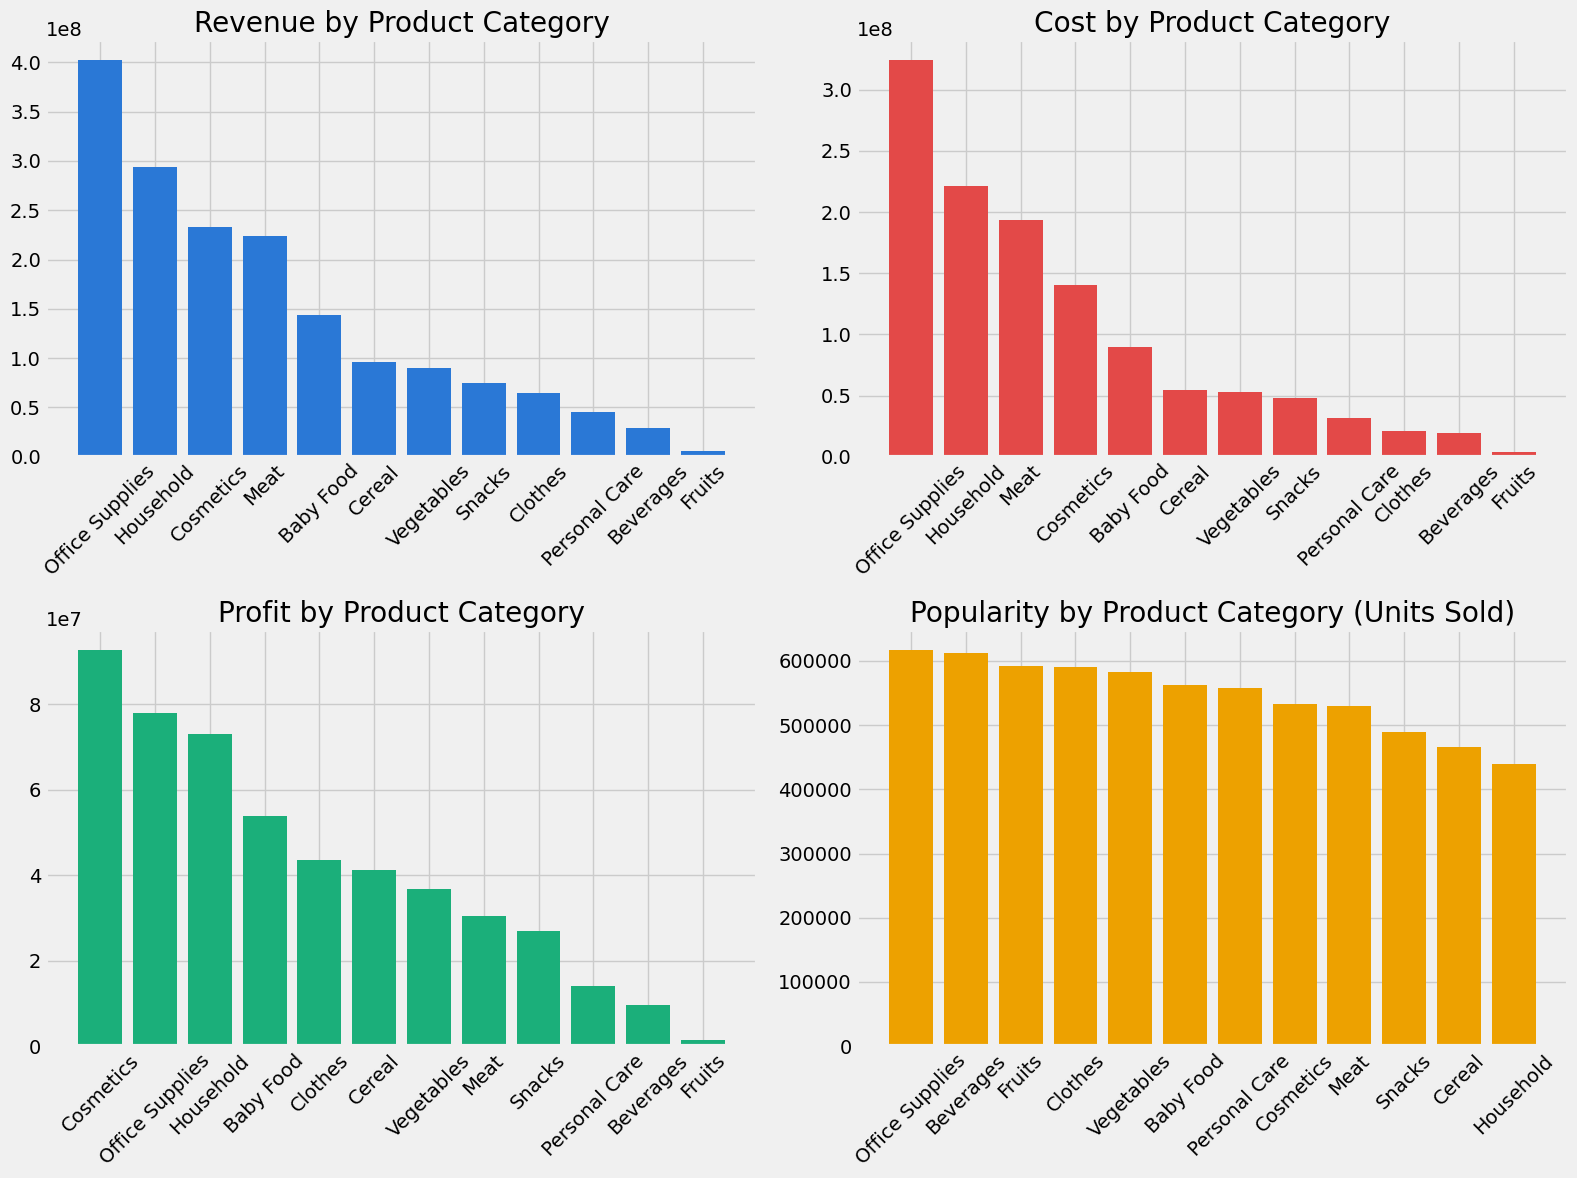

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(revenue_by_category["product_category"], revenue_by_category["revenue"], color="#2a78d6")
axes[0, 0].set_title("Revenue by Product Category")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].bar(cost_by_category["product_category"], cost_by_category["cost"], color="#e34948")
axes[0, 1].set_title("Cost by Product Category")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].bar(profit_by_category["product_category"], profit_by_category["profit"], color="#1baf7a")
axes[1, 0].set_title("Profit by Product Category")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].bar(popularity_by_category["product_category"], popularity_by_category["units_sold"], color="#eda100")
axes[1, 1].set_title("Popularity by Product Category (Units Sold)")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Office Supplies and Household lead in both revenue (\~\$400M and \~\$295M) and cost, reflecting their higher price per unit. However, Cosmetics ranks first in total profit (~$9.2M) despite ranking only third in revenue, indicating a notably higher profit margin than the top revenue categories. Popularity, measured by total units sold, tells a different story: Office Supplies and Beverages are sold in the highest volumes (600K+ units), while Household — the top revenue category — ranks last in units sold. This confirms that revenue leadership is driven by price per unit rather than purchase volume, and that the most profitable category isn't necessarily the top seller by revenue or volume

In [ ]:
# grouping by each metric (country_code)

# Revenue by country
revenue_by_country = events.groupby("country_code")["revenue"].sum().reset_index()

# Costs by country
cost_by_country = events.groupby("country_code")["cost"].sum().reset_index()

# Profit by country
profit_by_country = events.groupby("country_code")["profit"].sum().reset_index()

# Popularity by country
popularity_by_country = events.groupby("country_code")["units_sold"].sum().reset_index()

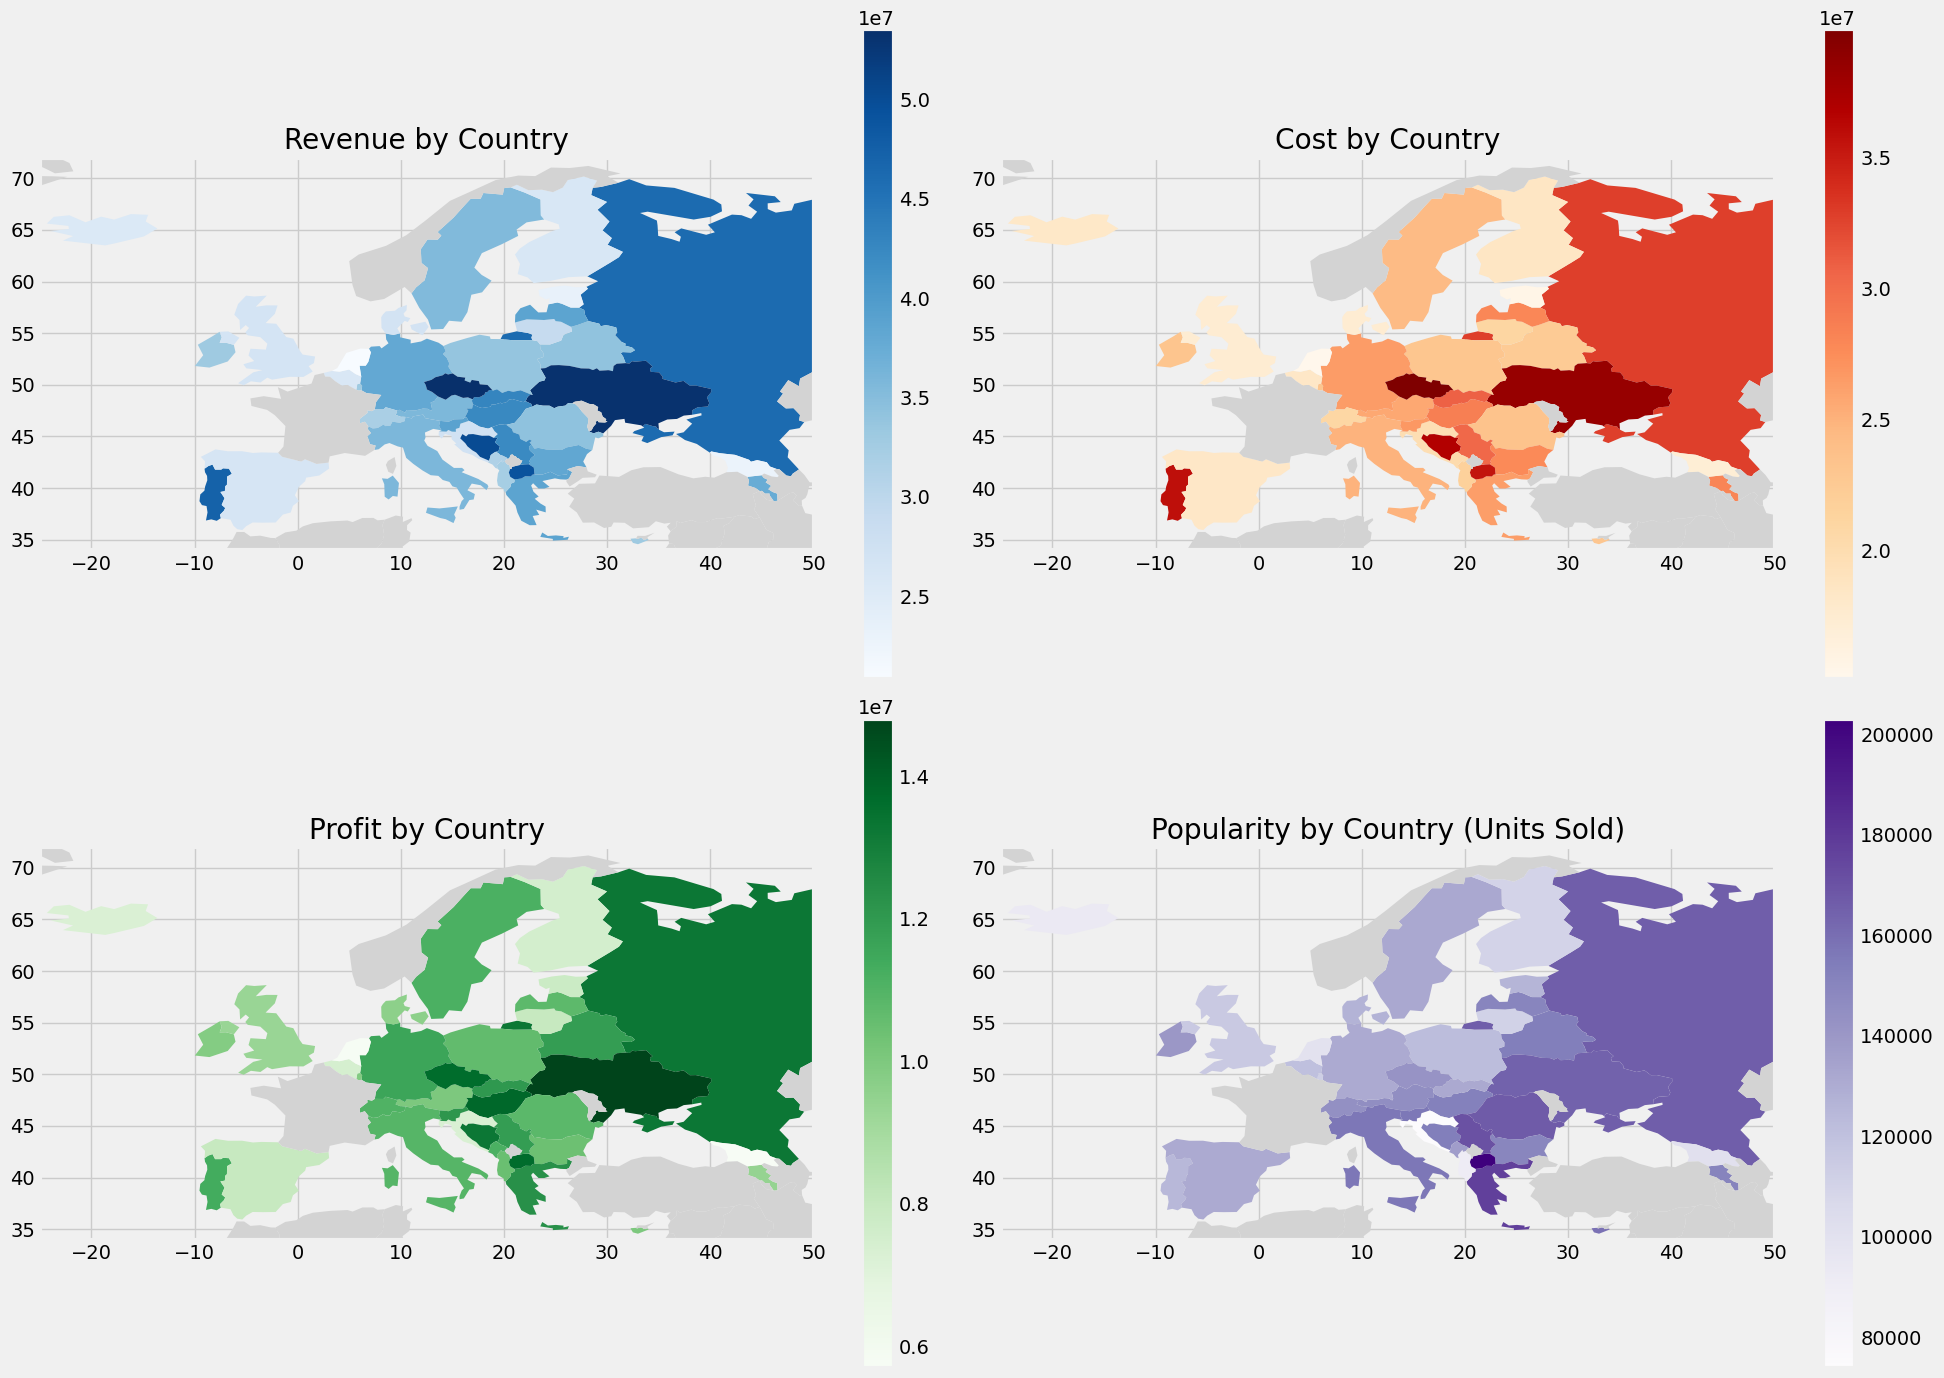

In [ ]:
import geopandas as gpd

world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

metrics = [
    (revenue_by_country, "revenue", "Revenue by Country", "Blues", axes[0, 0]),
    (cost_by_country, "cost", "Cost by Country", "OrRd", axes[0, 1]),
    (profit_by_country, "profit", "Profit by Country", "Greens", axes[1, 0]),
    (popularity_by_country, "units_sold", "Popularity by Country (Units Sold)", "Purples", axes[1, 1]),
]

for data, col, title, cmap, ax in metrics:
    merged_map = world.merge(data, left_on="ISO_A3", right_on="country_code", how="left")
    merged_map.plot(column=col, cmap=cmap, legend=True, ax=ax,
                     missing_kwds={"color": "lightgrey", "label": "No data"})
    ax.set_title(title)
    ax.set_xlim(-25, 50)
    ax.set_ylim(34, 72)

plt.tight_layout()
plt.show()

#### The analysis of geographical visualizations reveals that the Unknown category dominates all metrics (over 103M in revenue and 404K units sold), potentially representing one or multiple unidentified countries. Among the clearly identified regions, the Czech Republic and Ukraine lead in revenue (around 53M each); however, the Czech Republic drops out of the top profit list entirely, most likely due to a lower profit margin (a smaller gap between unit price and unit cost) rather than expenses being high in absolute terms, giving way to Ukraine, which demonstrates the best balance of scale and profitability. At the same time, a notable trend is observed among European microstates (Andorra, San Marino, and Malta): despite small market volumes, they generate high net profits, suggesting a notably higher profit margin relative to their size, whereas Macedonia, conversely, is one of the leaders in units sold but yields lower financial returns.

In [ ]:
# grouping by each metric (region)

# Revenue by region
revenue_by_region = events.groupby("region")["revenue"].sum().reset_index()
revenue_by_region = revenue_by_region.sort_values("revenue", ascending=False)

# Costs by region
cost_by_region = events.groupby("region")["cost"].sum().reset_index()
cost_by_region = cost_by_region.sort_values("cost", ascending=False)

# Profit by region
profit_by_region = events.groupby("region")["profit"].sum().reset_index()
profit_by_region = profit_by_region.sort_values("profit", ascending=False)

# Popularity by region
popularity_by_region = events.groupby("region")["units_sold"].sum().reset_index()
popularity_by_region = popularity_by_region.sort_values("units_sold", ascending=False)

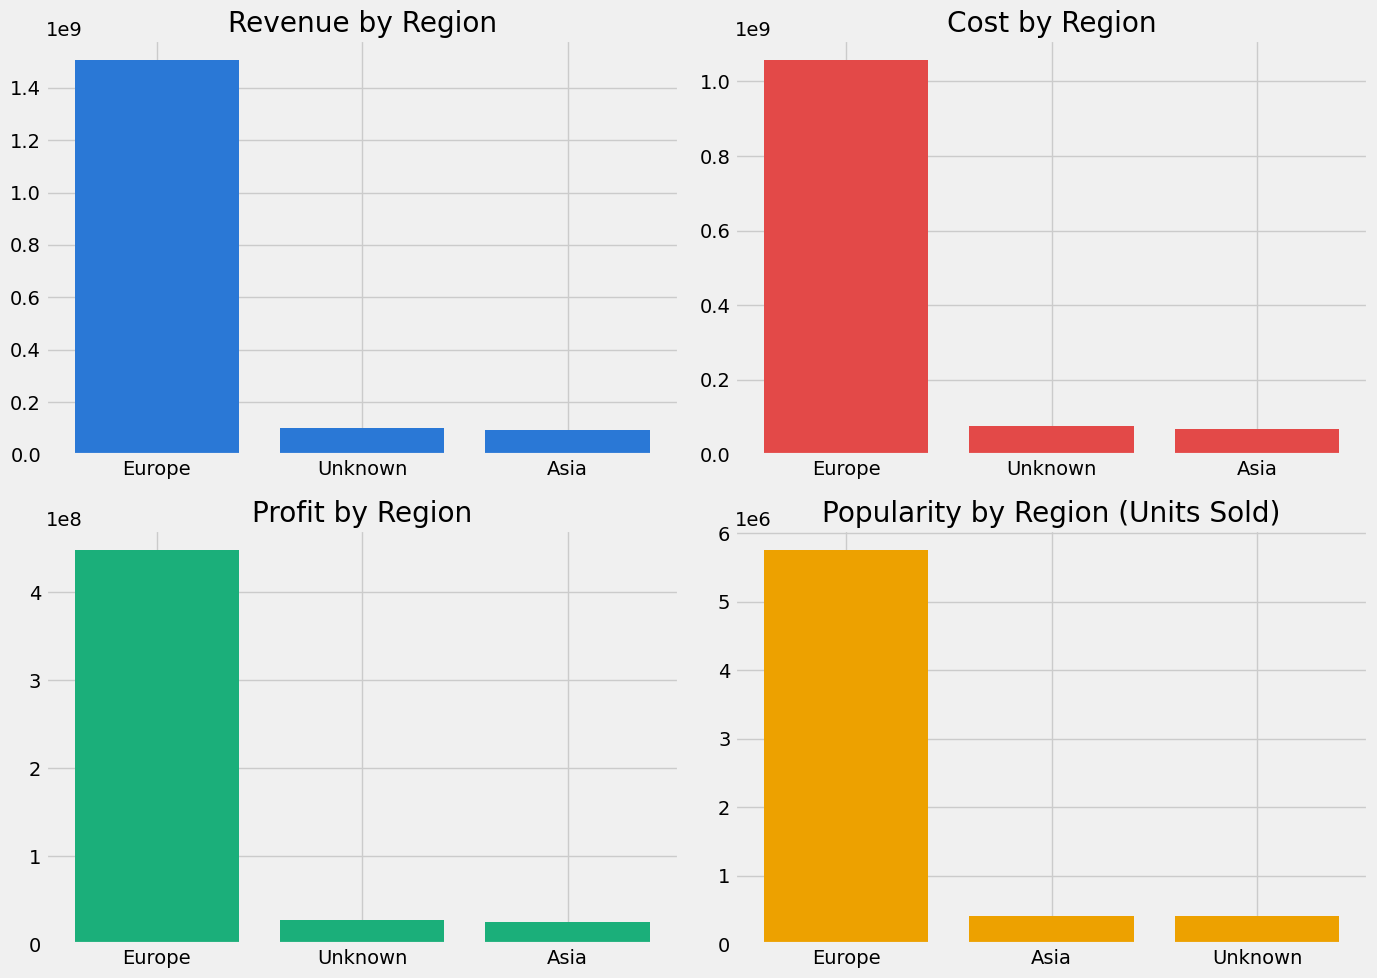

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

data = revenue_by_region
axes[0, 0].bar(data["region"], data["revenue"], color="#2a78d6")
axes[0, 0].set_title("Revenue by Region")

data = cost_by_region
axes[0, 1].bar(data["region"], data["cost"], color="#e34948")
axes[0, 1].set_title("Cost by Region")

data = profit_by_region
axes[1, 0].bar(data["region"], data["profit"], color="#1baf7a")
axes[1, 0].set_title("Profit by Region")

data = popularity_by_region
axes[1, 1].bar(data["region"], data["units_sold"], color="#eda100")
axes[1, 1].set_title("Popularity by Region (Units Sold)")

plt.tight_layout()
plt.show()

#### Europe overwhelmingly dominates every metric — revenue (\~\$1.51B), cost (\~\$1.06B), profit (\~\$448.6M), and units sold (~5.76M) — which is expected, since nearly all countries in the dataset are European. Asia (Armenia and Georgia) and Unknown contribute comparatively small and similar amounts across all four metrics (roughly $25–28M in profit each, 400K+ units sold each). Given how heavily skewed the dataset is toward Europe, the region breakdown offers limited analytical value.

In [ ]:
# grouping by each metric (sub_region)

# Revenue by sub_region
revenue_by_subregion = events.groupby("sub_region")["revenue"].sum().reset_index()
revenue_by_subregion = revenue_by_subregion.sort_values("revenue", ascending=False)

# Costs by sub_region
cost_by_subregion = events.groupby("sub_region")["cost"].sum().reset_index()
cost_by_subregion = cost_by_subregion.sort_values("cost", ascending=False)

# Profit by sub_region
profit_by_subregion = events.groupby("sub_region")["profit"].sum().reset_index()
profit_by_subregion = profit_by_subregion.sort_values("profit", ascending=False)

# Popularity by sub_region
popularity_by_subregion = events.groupby("sub_region")["units_sold"].sum().reset_index()
popularity_by_subregion = popularity_by_subregion.sort_values("units_sold", ascending=False)

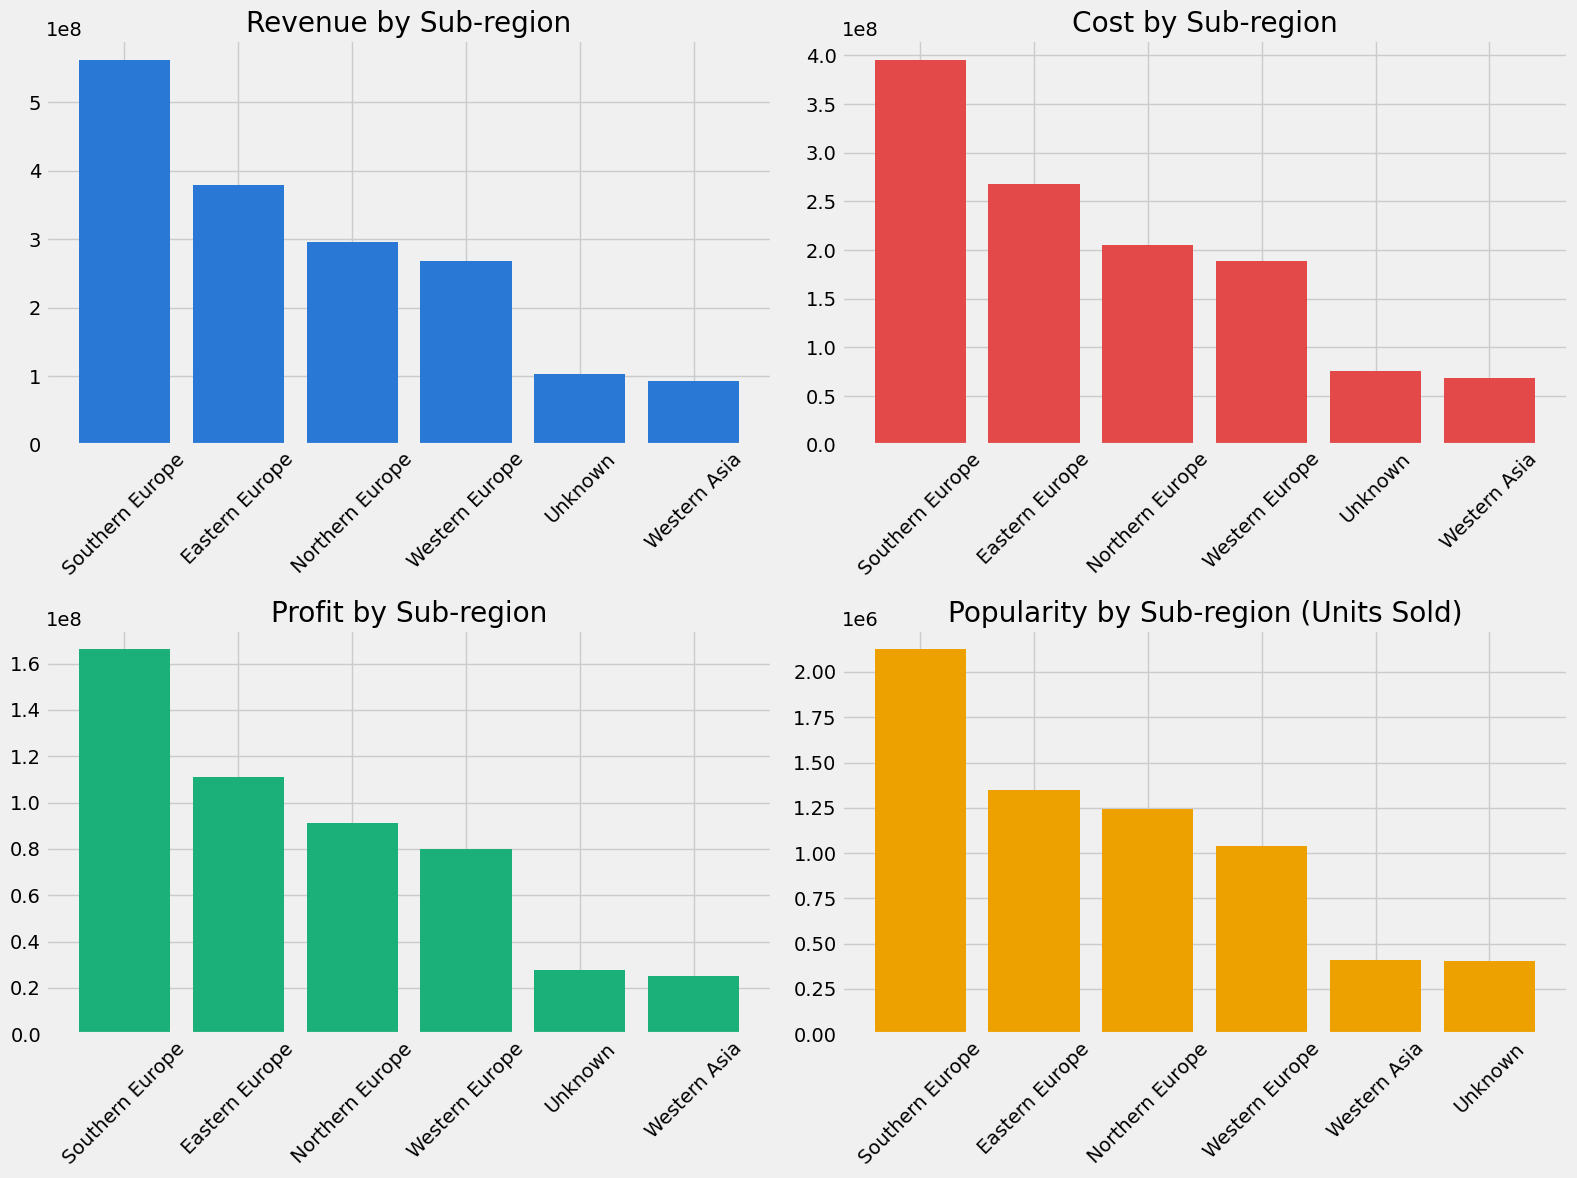

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

data = revenue_by_subregion
axes[0, 0].bar(data["sub_region"], data["revenue"], color="#2a78d6")
axes[0, 0].set_title("Revenue by Sub-region")
axes[0, 0].tick_params(axis="x", rotation=45)

data = cost_by_subregion
axes[0, 1].bar(data["sub_region"], data["cost"], color="#e34948")
axes[0, 1].set_title("Cost by Sub-region")
axes[0, 1].tick_params(axis="x", rotation=45)

data = profit_by_subregion
axes[1, 0].bar(data["sub_region"], data["profit"], color="#1baf7a")
axes[1, 0].set_title("Profit by Sub-region")
axes[1, 0].tick_params(axis="x", rotation=45)

data = popularity_by_subregion
axes[1, 1].bar(data["sub_region"], data["units_sold"], color="#eda100")
axes[1, 1].set_title("Popularity by Sub-region (Units Sold)")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Southern Europe is the clear leader across all four metrics — highest revenue (\~\$562M), profit (\~\$166M), and units sold (~2.13M) — consistent with earlier country-level findings, where several top-performing countries (Macedonia, San Marino, Andorra, Greece) belong to this sub-region. The ranking order (Southern Europe > Eastern Europe > Northern Europe > Western Europe) stays consistent across revenue, cost, profit, and popularity, indicating a fairly proportional relationship between these metrics at the sub-region level, unlike the more uneven patterns seen among individual countries. Notably, Western Europe ranks lowest among the four main sub-regions on every metric, despite commonly being associated with larger, wealthier economies (Germany, France, UK) — suggesting the company's market presence there may be comparatively smaller or less developed than in Southern or Eastern Europe.

In [ ]:
# grouping by each metric (sales_channel)

# Revenue by sales_channel
revenue_by_channel = events.groupby("sales_channel")["revenue"].sum().reset_index()
revenue_by_channel = revenue_by_channel.sort_values("revenue", ascending=False)

# Costs by sales_channel
cost_by_channel = events.groupby("sales_channel")["cost"].sum().reset_index()
cost_by_channel = cost_by_channel.sort_values("cost", ascending=False)

# Profit by sales_channel
profit_by_channel = events.groupby("sales_channel")["profit"].sum().reset_index()
profit_by_channel = profit_by_channel.sort_values("profit", ascending=False)

# Popularity by sales_channel
popularity_by_channel = events.groupby("sales_channel")["units_sold"].sum().reset_index()
popularity_by_channel = popularity_by_channel.sort_values("units_sold", ascending=False)

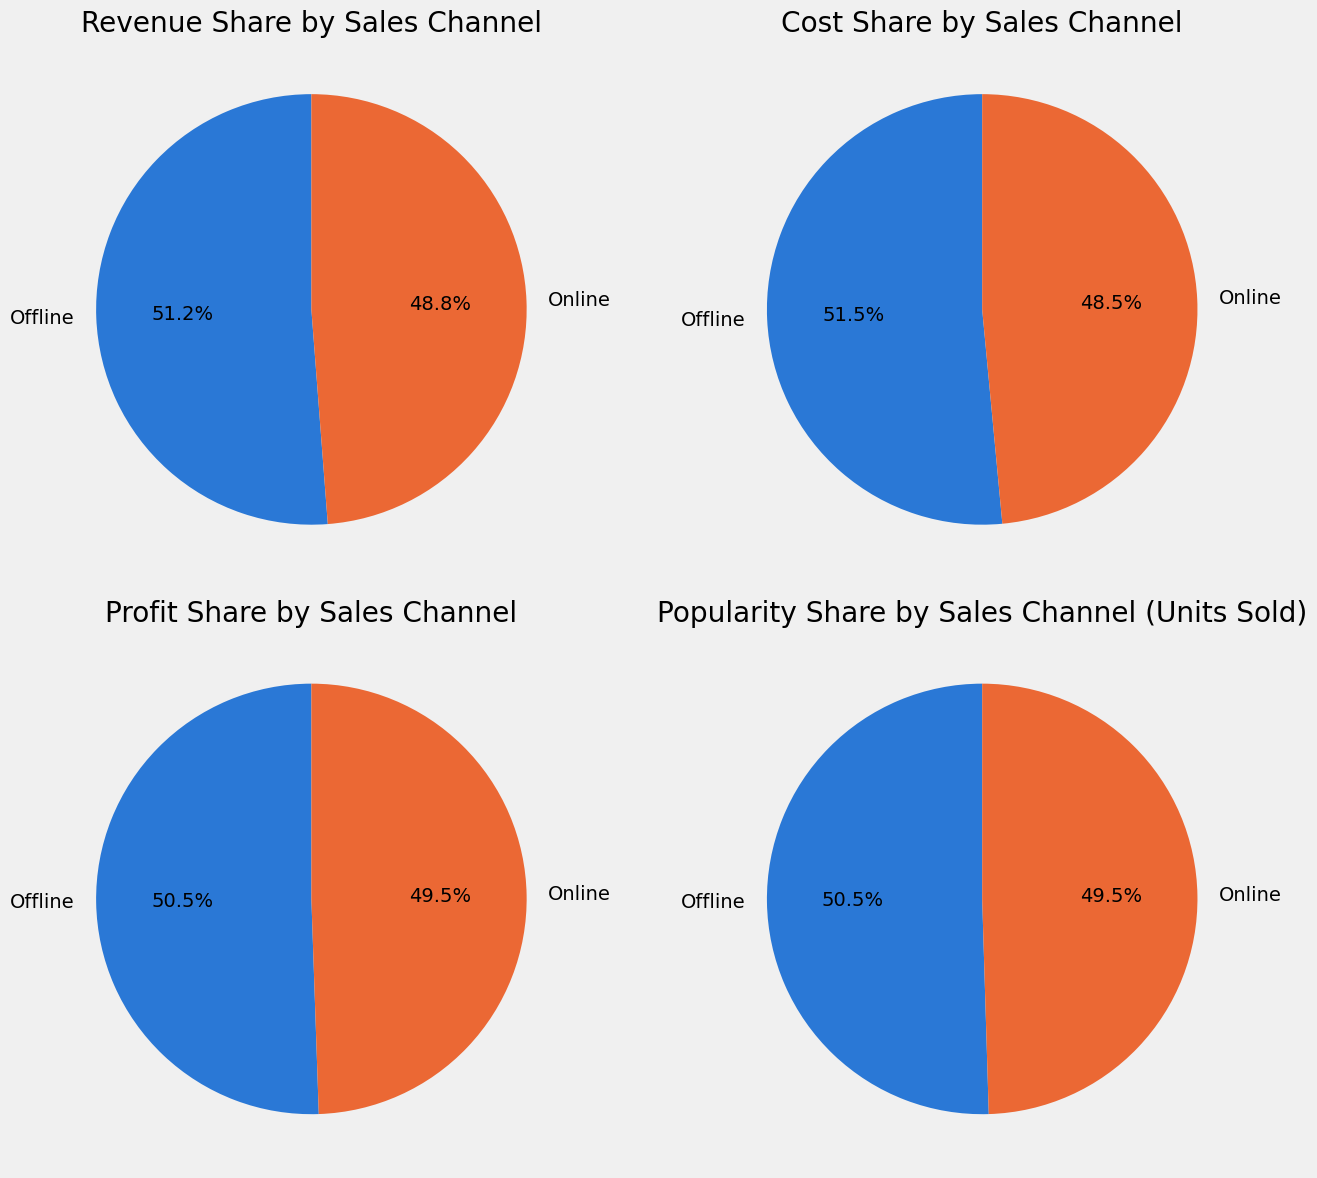

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

colors = ["#2a78d6", "#eb6834"]

axes[0, 0].pie(revenue_by_channel["revenue"], labels=revenue_by_channel["sales_channel"],
               autopct="%1.1f%%", colors=colors, startangle=90)
axes[0, 0].set_title("Revenue Share by Sales Channel")

axes[0, 1].pie(cost_by_channel["cost"], labels=cost_by_channel["sales_channel"],
               autopct="%1.1f%%", colors=colors, startangle=90)
axes[0, 1].set_title("Cost Share by Sales Channel")

axes[1, 0].pie(profit_by_channel["profit"], labels=profit_by_channel["sales_channel"],
               autopct="%1.1f%%", colors=colors, startangle=90)
axes[1, 0].set_title("Profit Share by Sales Channel")

axes[1, 1].pie(popularity_by_channel["units_sold"], labels=popularity_by_channel["sales_channel"],
               autopct="%1.1f%%", colors=colors, startangle=90)
axes[1, 1].set_title("Popularity Share by Sales Channel (Units Sold)")

plt.tight_layout()
plt.show()

#### Sales are almost evenly split between Offline and Online channels across all four metrics: revenue (51.2% vs 48.8%), cost (51.5% vs 48.5%), profit (50.5% vs 49.5%), and units sold (50.5% vs 49.5%). Offline holds a slight edge in every category, but the gap is small and consistent, indicating that neither channel significantly outperforms the other. This suggests the company maintains a well-balanced, diversified sales strategy rather than relying heavily on one channel over the other.

## Delivery Time Analysis

In [ ]:
# Calculating the delivery time (in days)

events["delivery_time_days"] = (events["ship_date"] - events["order_date"]).dt.days
events[["order_date", "ship_date", "delivery_time_days"]].head()

,order_date,ship_date,delivery_time_days
0,2014-10-08,2014-10-18,10
1,2016-08-11,2016-08-11,0
2,2014-07-18,2014-08-11,24
3,2017-05-13,2017-06-13,31
4,2012-08-11,2012-09-18,38


In [ ]:
# Average delivery time by product_category
delivery_by_category = events.groupby("product_category")["delivery_time_days"].mean().reset_index()
delivery_by_category = delivery_by_category.sort_values("delivery_time_days", ascending=False)

# Average delivery time by country
delivery_by_country = events.groupby("country")["delivery_time_days"].mean().reset_index()
delivery_by_country = delivery_by_country.sort_values("delivery_time_days", ascending=False)

# Average delivery time by region
delivery_by_region = events.groupby("region")["delivery_time_days"].mean().reset_index()
delivery_by_region = delivery_by_region.sort_values("delivery_time_days", ascending=False)

print(delivery_by_category)
print(delivery_by_country)
print(delivery_by_region)

   product_category  delivery_time_days
2            Cereal           27.184466
8   Office Supplies           26.707317
0         Baby Food           26.339286
4         Cosmetics           25.912281
7              Meat           25.909091
10           Snacks           25.543689
5            Fruits           24.419643
1         Beverages           24.123967
6         Household           23.938144
11       Vegetables           23.491228
3           Clothes           23.104762
9     Personal Care           20.763158
                   country  delivery_time_days
18                 Hungary           32.640000
15                 Georgia           29.695652
3                  Austria           28.500000
38                Slovakia           28.466667
25              Luxembourg           27.750000
24               Lithuania           27.560000
32                  Poland           27.464286
35                  Russia           27.375000
28                  Monaco           26.846154
7         

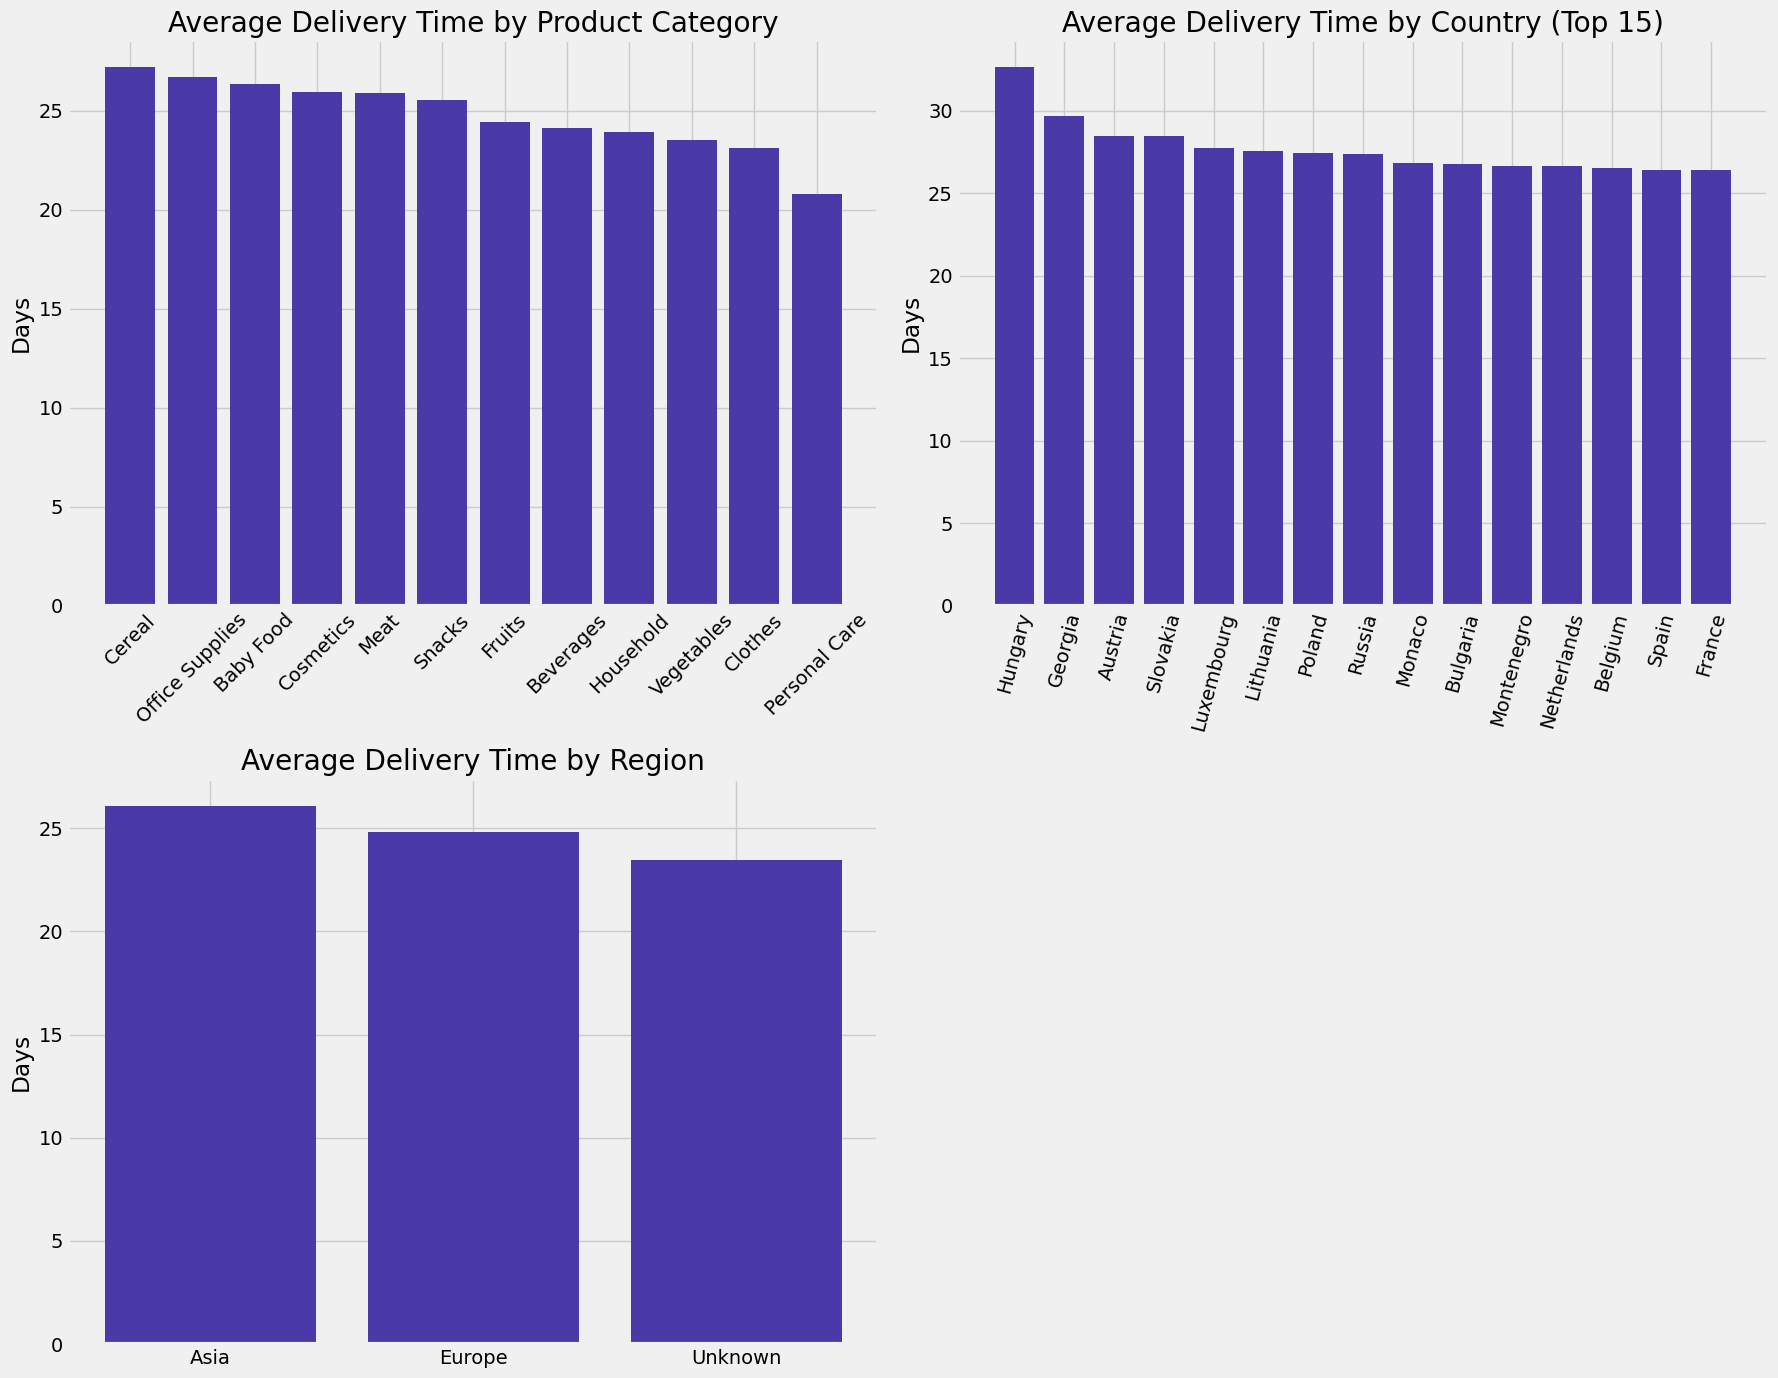

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

data = delivery_by_category
axes[0, 0].bar(data["product_category"], data["delivery_time_days"], color="#4a3aa7")
axes[0, 0].set_title("Average Delivery Time by Product Category")
axes[0, 0].set_ylabel("Days")
axes[0, 0].tick_params(axis="x", rotation=45)

data = delivery_by_country.head(15)
axes[0, 1].bar(data["country"], data["delivery_time_days"], color="#4a3aa7")
axes[0, 1].set_title("Average Delivery Time by Country (Top 15)")
axes[0, 1].set_ylabel("Days")
axes[0, 1].tick_params(axis="x", rotation=75)

data = delivery_by_region
axes[1, 0].bar(data["region"], data["delivery_time_days"], color="#4a3aa7")
axes[1, 0].set_title("Average Delivery Time by Region")
axes[1, 0].set_ylabel("Days")

fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

#### Delivery time shows very little variation across all three dimensions. By product category, times range narrowly from \~21 days (Personal Care) to \~27 days (Cereal) — a spread of only about 6 days, with no category standing out as unusually fast or slow. By country, the top 15 range from \~27 to \~33 days, with Hungary slightly higher than the rest but still within a comparable range. By region, Asia, Europe, and Unknown are nearly identical (~23–26 days). Overall, this suggests delivery time is not meaningfully influenced by product category, country, or region — the logistics process appears consistent across the entire dataset, likely following a standardized shipping process regardless of what is being shipped or where.

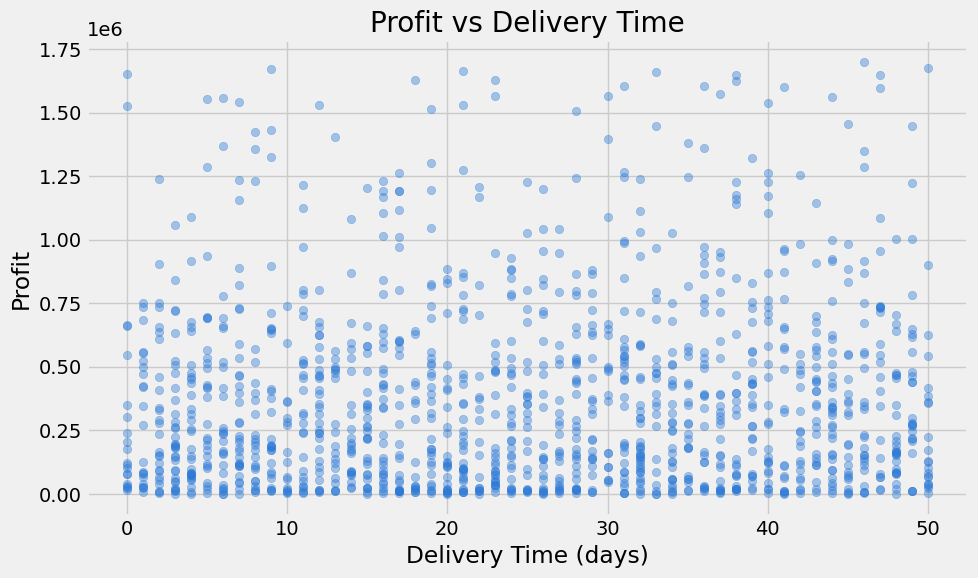

In [ ]:
# The relationship between profit and delivery time
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(events["delivery_time_days"], events["profit"], alpha=0.4, color="#2a78d6")
ax.set_xlabel("Delivery Time (days)")
ax.set_ylabel("Profit")
ax.set_title("Profit vs Delivery Time")
plt.tight_layout()
plt.show()

#### The scatter plot of profit against delivery time shows no visible relationship between the two variables. Points are scattered evenly across the entire range of delivery times (0 to 50 days), with both very low and very high profit values appearing at every delivery time, regardless of whether delivery was fast or slow. There is no upward or downward trend in the data. This suggests that how long an order takes to ship has no meaningful impact on how profitable that order is — profit is likely driven by other factors, such as product category or unit pricing, rather than shipping speed.

## Sales Trends

In [ ]:
events["order_year"] = events["order_date"].dt.year

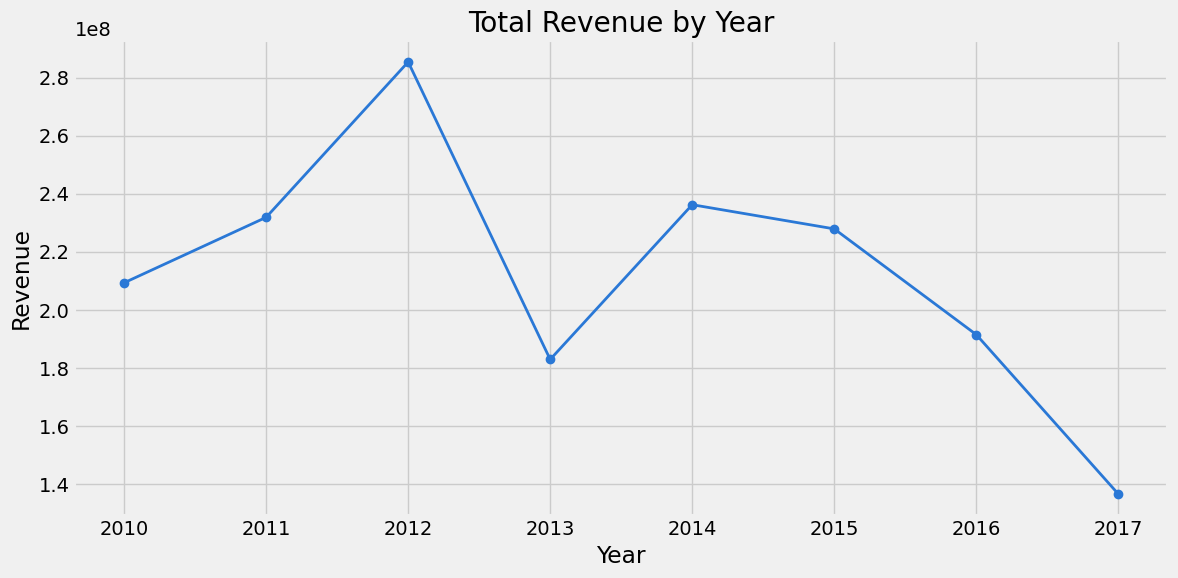

In [ ]:
sales_by_year = events.groupby("order_year")["revenue"].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(sales_by_year["order_year"], sales_by_year["revenue"], marker="o", color="#2a78d6", linewidth=2)
ax.set_title("Total Revenue by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Revenue")
ax.grid(True)
plt.tight_layout()
plt.show()

#### Total revenue shows no consistent long-term trend over the 8-year period (2010–2017), but rather a volatile, non-linear pattern. Revenue peaked in 2012 (\~\$285M) after two years of growth, then dropped sharply in 2013 (\~\$183M). A partial recovery followed in 2014–2015 (\~\$235–240M), before entering a steady decline through 2016 and 2017, ending at the lowest point of the entire period (~$135M in 2017). This suggests the business experienced meaningful fluctuations rather than steady growth or decline, with the most recent years showing a downward trend.

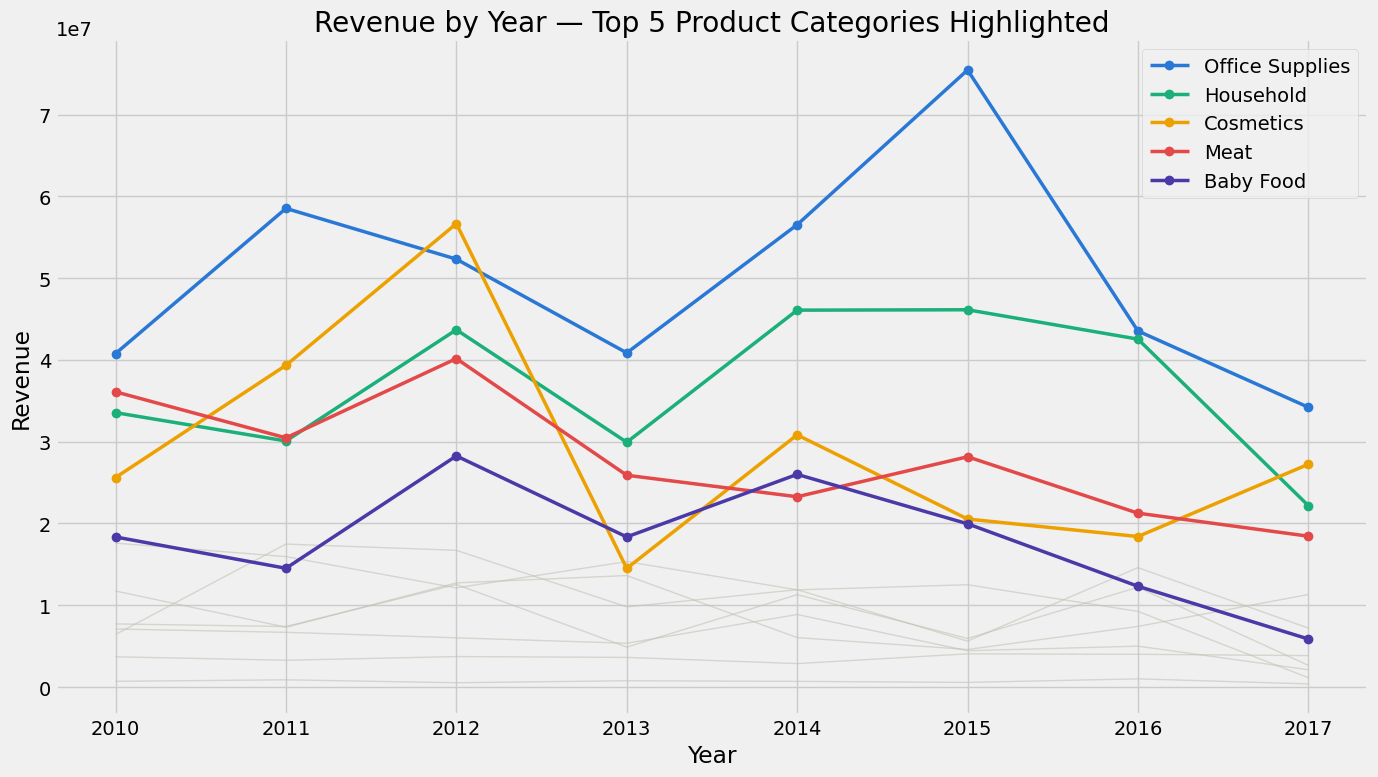

In [ ]:
# Yearly revenue dynamics by product category

top5_categories = revenue_by_category.head(5)["product_category"].tolist()

highlight_colors = ["#2a78d6", "#1baf7a", "#eda100", "#e34948", "#4a3aa7"]

fig, ax = plt.subplots(figsize=(14, 8))

for category in revenue_year_category["product_category"].unique():
    if category not in top5_categories:
        data = revenue_year_category[revenue_year_category["product_category"] == category]
        ax.plot(data["order_year"], data["revenue"], color="#c3c2b7", linewidth=1, alpha=0.6, zorder=1)

for i, category in enumerate(top5_categories):
    data = revenue_year_category[revenue_year_category["product_category"] == category]
    ax.plot(data["order_year"], data["revenue"], marker="o", label=category,
            color=highlight_colors[i], linewidth=2.5, zorder=2)

ax.set_title("Revenue by Year — Top 5 Product Categories Highlighted")
ax.set_xlabel("Year")
ax.set_ylabel("Revenue")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#### Among the top 5 revenue categories, Office Supplies is the most unstable — it jumps up sharply to its highest point in 2015 (\~\$76M, the biggest single value in the whole dataset), then drops fast by 2017. Cosmetics changes the most dramatically of all five: it grows from \~\$26M in 2010 to \~\$57M in 2012, then falls hard to ~$14M just one year later, in 2013. Household behaves very differently — its line is much smoother, rising slowly to a peak in 2014–2015 and then declining gradually, without sudden jumps. Meat and Baby Food move up and down in a similar, moderate wave pattern. What stands out most is that all five categories end up much lower in 2017 than at their highest point earlier in the dataset — this matches the overall revenue drop we saw for the whole company, which suggests the decline in recent years is a general problem, not something caused by just one category doing badly.

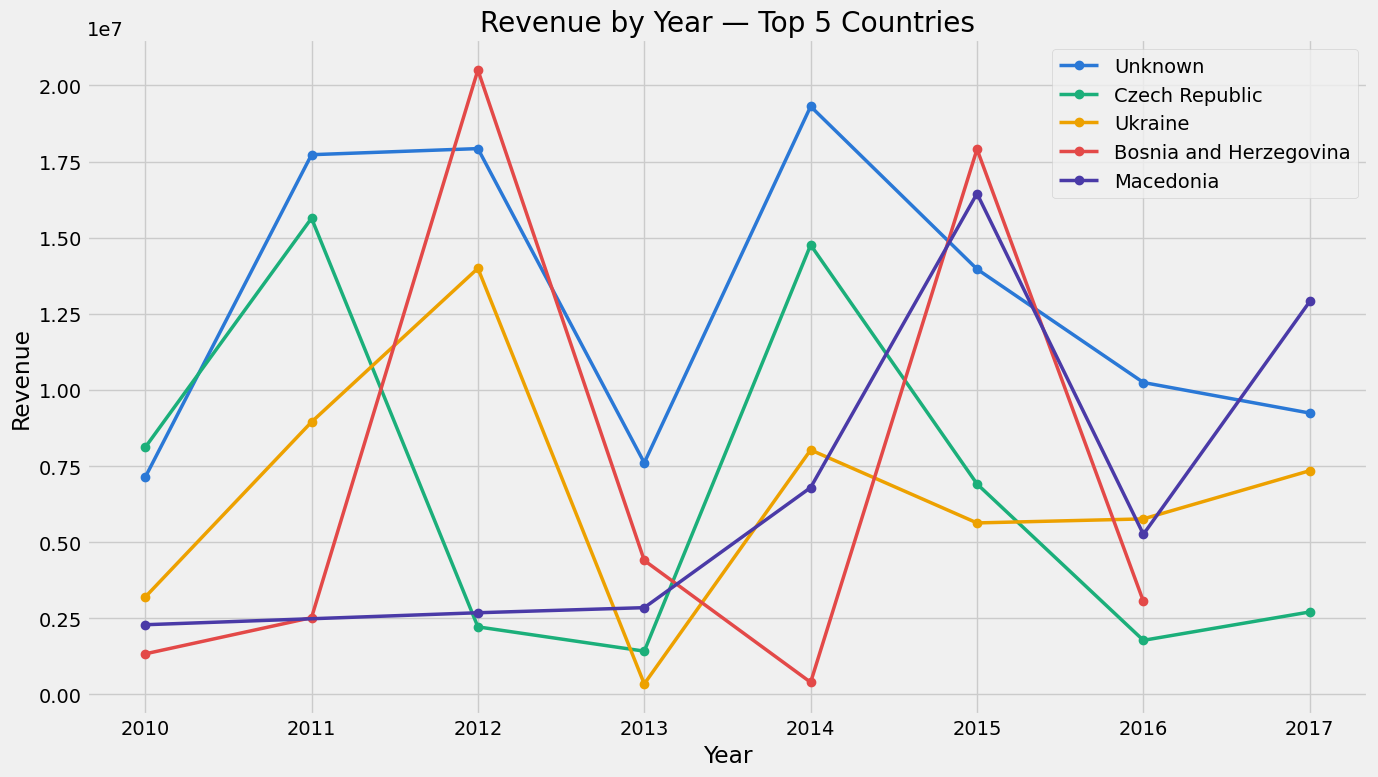

In [ ]:
# Yearly revenue dynamics by country

revenue_by_country = events.groupby("country")["revenue"].sum().reset_index()
top5_country = revenue_by_country.sort_values("revenue", ascending=False).head(5)["country"].tolist()

revenue_year_country = events[events["country"].isin(top5_country)].groupby(["order_year", "country"])["revenue"].sum().reset_index()

colors = ["#2a78d6", "#1baf7a", "#eda100", "#e34948", "#4a3aa7"]

fig, ax = plt.subplots(figsize=(14, 8))

for i, country in enumerate(top5_country):
    data = revenue_year_country[revenue_year_country["country"] == country]
    ax.plot(data["order_year"], data["revenue"], marker="o", label=country, color=colors[i], linewidth=2.5)

ax.set_title("Revenue by Year — Top 5 Countries")
ax.set_xlabel("Year")
ax.set_ylabel("Revenue")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#### Revenue by year for the top 5 countries shows extreme volatility, with sharp spikes and drops that don't follow any clear, consistent pattern. Bosnia and Herzegovina swings the most dramatically — from near zero in 2010 to the highest point on the chart in 2012 (~$20.5M), then back down near zero by 2014. Macedonia stays low through 2010–2013, then rises sharply from 2014 onward, with peaks in 2015 and 2017. This kind of erratic, unpredictable movement is likely explained by the small number of orders per country per year — with so few data points, a single large order can swing an entire year's total up or down.

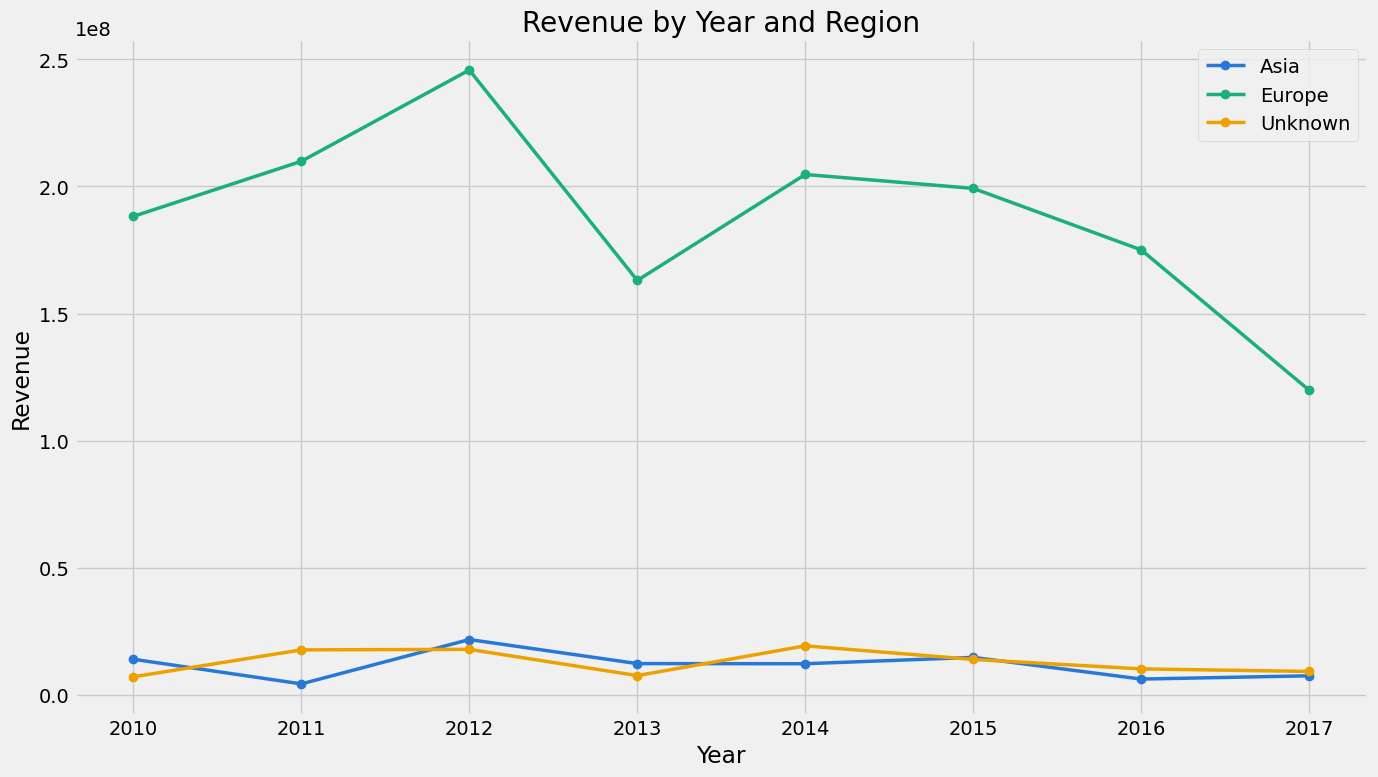

In [ ]:
# Yearly revenue dynamics by region

revenue_year_region = events.groupby(["order_year", "region"])["revenue"].sum().reset_index()

colors = ["#2a78d6", "#1baf7a", "#eda100"]

fig, ax = plt.subplots(figsize=(14, 8))

regions = revenue_year_region["region"].unique()
for i, region in enumerate(regions):
    data = revenue_year_region[revenue_year_region["region"] == region]
    ax.plot(data["order_year"], data["revenue"], marker="o", label=region, color=colors[i], linewidth=2.5)

ax.set_title("Revenue by Year and Region")
ax.set_xlabel("Year")
ax.set_ylabel("Revenue")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#### Europe's revenue trend closely mirrors the overall company-wide pattern seen earlier — a peak in 2012, a sharp drop in 2013, partial recovery in 2014–2015, and then a steady decline through 2017 down to the lowest point in the whole period. This makes sense, since Europe accounts for roughly 93% of total revenue, so its ups and downs essentially drive the company's overall trend. Asia and Unknown, by contrast, stay low and relatively flat across all eight years, moving slightly up and down without any clear long-term direction — their small size means they don't meaningfully affect the total revenue trend either way.

In [ ]:
# Determining the day of the week for each order

events["order_day_name"] = events["order_date"].dt.day_name()
events[["order_date", "order_day_name"]].head()

,order_date,order_day_name
0,2014-10-08,Wednesday
1,2016-08-11,Thursday
2,2014-07-18,Friday
3,2017-05-13,Saturday
4,2012-08-11,Saturday


In [ ]:
# Total revenue by day of the week

revenue_by_day = events.groupby("order_day_name")["revenue"].sum().reset_index()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
revenue_by_day["order_day_name"] = pd.Categorical(revenue_by_day["order_day_name"], categories=day_order, ordered=True)
revenue_by_day = revenue_by_day.sort_values("order_day_name")
print(revenue_by_day)

  order_day_name       revenue
1         Monday  2.754685e+08
5        Tuesday  2.135239e+08
6      Wednesday  2.612157e+08
4       Thursday  2.149222e+08
0         Friday  2.638070e+08
2       Saturday  2.336411e+08
3         Sunday  2.395510e+08


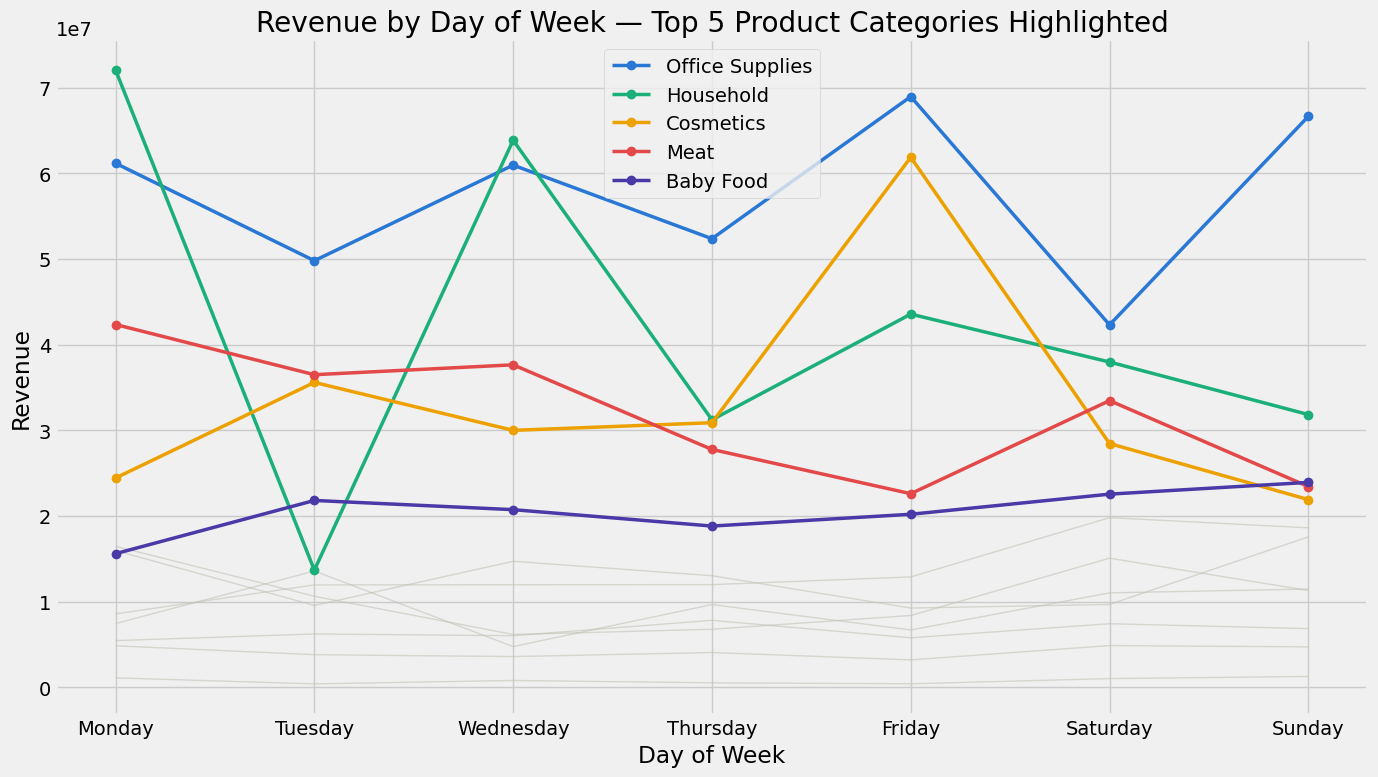

In [ ]:
# Daily revenue by day of the week and product category

top5_categories = revenue_by_category.head(5)["product_category"].tolist()
highlight_colors = ["#2a78d6", "#1baf7a", "#eda100", "#e34948", "#4a3aa7"]

fig, ax = plt.subplots(figsize=(14, 8))

for category in revenue_day_category["product_category"].unique():
    if category not in top5_categories:
        data = revenue_day_category[revenue_day_category["product_category"] == category]
        ax.plot(data["order_day_name"], data["revenue"], color="#c3c2b7", linewidth=1, alpha=0.6, zorder=1)

for i, category in enumerate(top5_categories):
    data = revenue_day_category[revenue_day_category["product_category"] == category]
    ax.plot(data["order_day_name"], data["revenue"], marker="o", label=category,
            color=highlight_colors[i], linewidth=2.5, zorder=2)

ax.set_title("Revenue by Day of Week — Top 5 Product Categories Highlighted")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Revenue")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#### Looking at revenue by day of week, Household stands out as the clearest case of weekly seasonality: it peaks sharply on Monday (\~\$72M) and Wednesday (\~\$64M), but drops to the lowest point on the entire chart on Tuesday (\~\$13M) — a swing of nearly 6x between neighboring days. Cosmetics shows a similar pattern, spiking heavily on Friday (\~\$62M) while staying much lower (\~\$22–36M) on every other day. In contrast, Office Supplies stays consistently high throughout the whole week (~$42–69M) without sharp drops, suggesting steady demand regardless of the day. Meat and Baby Food show only mild ups and downs. Based on this, Household and Cosmetics are the two categories that can reasonably be called "seasonal" within the week, since their sales are strongly tied to specific days rather than spread evenly.

# Product Conclusions
- Revenue is going down in recent years. It was highest in 2012 (\~\$285M), had a smaller peak in 2015 (mostly because of Office Supplies), and then dropped to its lowest point in 2017 (~$135M). Almost every top category dropped too, and this matches what happened in Europe, which makes up about 93% of all revenue. It would be worth digging into why this is happening — more competition, market changes, pricing, etc.
- The categories that make the most money aren't always the most profitable. Office Supplies and Household bring in the most revenue, but Cosmetics actually makes the most profit, because it keeps a bigger share of what it earns. So it's worth looking at profit margin per category, not just total revenue, when deciding where to invest.
- Household sells in small amounts but earns a lot of money per sale, while Office Supplies and Beverages sell in huge amounts. This means marketing and stock planning should treat "expensive, rarely bought" products differently from "cheap, bought all the time" products.
- Small European countries do surprisingly well. Tiny countries like Andorra, San Marino, and Malta earn more profit and sell more, relative to their size, than expected. Meanwhile, bigger markets like Czech Republic bring in more total money but less profit. This suggests these small countries might be worth investing more in.
- Western Europe is doing worse than you'd expect. Even though it's a big, wealthy region, it comes last out of the four main European sub-regions in every measure we looked at. This could mean the company hasn't really broken into this market yet, even though people there likely have money to spend.
- Online and offline sales are balanced. Both channels contribute almost equally (48–52%) everywhere we checked, so the company isn't depending too much on just one way of selling.
- How long delivery takes doesn't affect profit, and it's pretty much the same across categories, countries, and regions. Shipping seems standardized and isn't something that makes a real difference here.
- Household and Cosmetics sell a lot more on certain days of the week than others, while Office Supplies sells steadily every day. For the "seasonal" categories, it could help to plan promotions, staff, or stock around their busiest days.